In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

K_CR         = 0.75
ROLL_MONTHS  = 36
TARGET_YEARS = [2030, 2040, 2050]

BASE     = Path(r"c:\Users\LucasMonero\Documents\data projects\Master Thesis\Project")
SIM_FILE = BASE / "Data/Simulated/mc_physical_variables_pniec.parquet"
RI_FILE  = BASE / "Data/Results/ri_annual_results_multiscenario.parquet"
CR_HIST  = BASE / "Data/Modelled/df_cr_modelled.parquet"
RI_HIST  = BASE / "Data/Results/ri_annual_results_hist.parquet"

## Data Loading

In [14]:
def load_data():
    sim = pd.read_parquet(SIM_FILE, columns=["sim_id", "date", "year", "month", "CR_sim"])
    sim["sim_id"] = sim["sim_id"].astype("int32")

    ri = pd.read_parquet(RI_FILE)
    ri = ri[(ri["pen_scenario"] == "pniec") & (ri["temp_scenario"] == "baseline")].copy()
    ri["sim_id"] = ri["sim_id"].astype("int32")
    ri = ri[["sim_id", "year", "RI_annual", "CR_annual"]].copy()
    ri["PR_annual"] = ri["RI_annual"] / ri["CR_annual"]

    cr_h = pd.read_parquet(CR_HIST, columns=["date", "year", "month", "capture_rate"])
    cr_h["date"]      = pd.to_datetime(cr_h["date"])
    cr_h["quarter"]   = ((cr_h["month"] - 1) // 3) + 1
    cr_h["payoff_cr"] = (K_CR - cr_h["capture_rate"]).clip(lower=0)

    ri_h = pd.read_parquet(RI_HIST, columns=["year", "RI_annual", "CR_annual"])
    ri_h["PR_annual"] = ri_h["RI_annual"] / ri_h["CR_annual"]

    return sim, ri, cr_h, ri_h


sim, ri, cr_h, ri_h = load_data()
print(f"sim  : {sim.shape}")
print(f"ri   : {ri.shape}")
print(f"cr_h : {cr_h.shape}")
print(f"ri_h : {ri_h.shape}")

sim  : (9131000, 5)
ri   : (25000, 5)
cr_h : (7670, 6)
ri_h : (21, 4)


## Step 0 — Monthly CR Aggregation (Simulation)

In [15]:
def step0_monthly_cr(sim):
    cr_monthly = (
        sim.groupby(["sim_id", "year", "month"])["CR_sim"]
        .mean()
        .reset_index()
    )
    cr_monthly.columns = ["sim_id", "year", "month", "CR_monthly"]
    assert len(cr_monthly) == 1_000 * 25 * 12, f"Unexpected shape: {len(cr_monthly)}"
    print(f"cr_monthly: {cr_monthly.shape}")
    return cr_monthly


cr_monthly = step0_monthly_cr(sim)

cr_monthly: (300000, 4)


## Step 1 — Premium Computation

In [16]:
def step1_premiums(cr_h, cr_monthly, K=K_CR, roll_months=ROLL_MONTHS):
    # 1a — historical rolling premium (36-month same-quarter window)
    records = []
    for year in range(2020, 2026):
        for month in range(1, 13):
            t       = pd.Timestamp(year=year, month=month, day=1)
            q       = ((month - 1) // 3) + 1
            w_start = t - pd.DateOffset(months=roll_months)
            w_end   = t - pd.Timedelta(days=1)
            mask    = (
                (cr_h["date"] >= w_start) &
                (cr_h["date"] <= w_end) &
                (cr_h["quarter"] == q)
            )
            prem = cr_h.loc[mask, "payoff_cr"].mean() if mask.sum() > 0 else np.nan
            records.append({"year": year, "month": month, "quarter": q, "premium_roll": prem})
    premium_roll = pd.DataFrame(records)

    # 1b — MC cross-section premium per (year, month)
    tmp = cr_monthly.copy()
    tmp["payoff"] = (K - tmp["CR_monthly"]).clip(lower=0)
    premium_mc = (
        tmp.groupby(["year", "month"])["payoff"]
        .mean()
        .reset_index()
        .rename(columns={"payoff": "premium_mc"})
    )
    premium_mc["quarter"] = ((premium_mc["month"] - 1) // 3) + 1

    print("premium_roll shape:", premium_roll.shape)
    print("premium_mc   shape:", premium_mc.shape)
    print(premium_roll.head(6).to_string(index=False, float_format="{:.5f}".format))
    return premium_roll, premium_mc


premium_roll, premium_mc = step1_premiums(cr_h, cr_monthly)

premium_roll shape: (72, 4)
premium_mc   shape: (300, 4)
 year  month  quarter  premium_roll
 2020      1        1       0.00000
 2020      2        1       0.00000
 2020      3        1       0.00000
 2020      4        2       0.00000
 2020      5        2       0.00164
 2020      6        2       0.00246


## Step 2 — Historical Backtest 2020–2025

 year  CR_annual  annual_payoff  annual_premium  net_pnl  RI_unhedged  RI_hedged
 2020     0.9937         0.0000          0.0041  -0.0041    1161.1956  1160.7964
 2021     1.0170         0.0000          0.0074  -0.0074    1156.1958  1155.4923
 2022     0.9862         0.0000          0.0074  -0.0074    1159.8942  1159.1664
 2023     0.9434         0.0000          0.0066  -0.0066    1059.6830  1059.0632
 2024     0.9368         0.0000          0.0174  -0.0174    1004.5943  1003.0375
 2025     0.9057         0.0000          0.0316  -0.0316     985.9093   983.0444


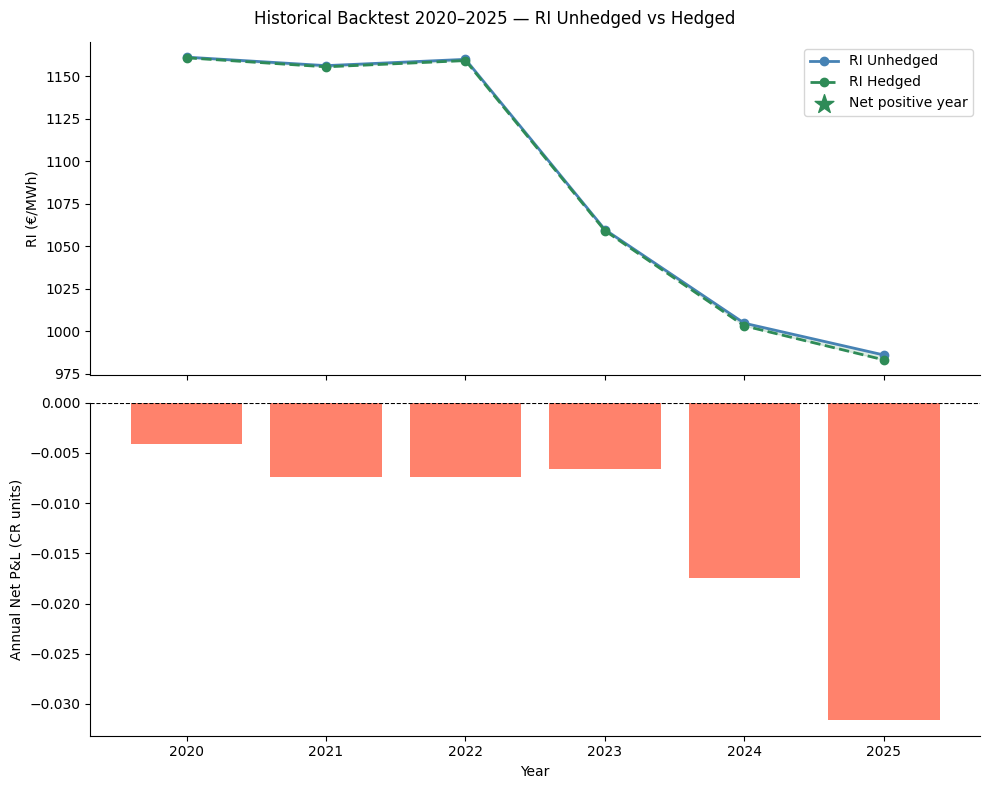

In [17]:
def step2_historical_backtest(cr_h, ri_h, premium_roll, K=K_CR):
    bt_m = (
        cr_h[cr_h["year"].between(2020, 2025)]
        .groupby(["year", "month"])["capture_rate"]
        .mean()
        .reset_index()
        .rename(columns={"capture_rate": "CR_hist_m"})
    )
    bt_m["payoff_m"] = (K - bt_m["CR_hist_m"]).clip(lower=0)
    bt_m = bt_m.merge(premium_roll[["year", "month", "premium_roll"]], on=["year", "month"])
    bt_m["net_m"] = bt_m["payoff_m"] - bt_m["premium_roll"]

    annual = (
        bt_m.groupby("year")
        .agg(annual_payoff=("payoff_m", "sum"),
             annual_premium=("premium_roll", "sum"),
             annual_net=("net_m", "sum"))
        .reset_index()
    )

    bt = ri_h[ri_h["year"].between(2020, 2025)].merge(annual, on="year")
    bt["RI_hedged"]   = bt["RI_annual"] + bt["PR_annual"] * bt["annual_net"] / 12
    bt["RI_unhedged"] = bt["RI_annual"]

    table = bt[["year", "CR_annual", "annual_payoff", "annual_premium", "annual_net",
                "RI_unhedged", "RI_hedged"]].copy()
    table.columns = ["year", "CR_annual", "annual_payoff", "annual_premium", "net_pnl",
                     "RI_unhedged", "RI_hedged"]
    print(table.to_string(index=False, float_format="{:.4f}".format))

    years   = bt["year"].values
    ri_unh  = bt["RI_unhedged"].values
    ri_hed  = bt["RI_hedged"].values
    net_pos = bt["annual_net"].values > 0
    net_v   = bt["annual_net"].values

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    ax = axes[0]
    ax.plot(years, ri_unh, color="steelblue", lw=2, marker="o", label="RI Unhedged")
    ax.plot(years, ri_hed, color="seagreen",  lw=2, marker="o", linestyle="--", label="RI Hedged")
    ax.fill_between(years, ri_unh, ri_hed, alpha=0.15, color="seagreen")
    ax.scatter(years[net_pos], ri_hed[net_pos], marker="*", s=200, color="seagreen",
               zorder=5, label="Net positive year")
    ax.set_ylabel("RI (€/MWh)")
    ax.legend()

    ax = axes[1]
    bar_colors = ["seagreen" if v > 0 else "tomato" for v in net_v]
    ax.bar(years, net_v, color=bar_colors, alpha=0.8)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.set_ylabel("Annual Net P&L (CR units)")
    ax.set_xlabel("Year")
    ax.set_xticks(years)

    fig.suptitle("Historical Backtest 2020–2025 — RI Unhedged vs Hedged")
    sns.despine()
    plt.tight_layout()
    plt.show()
    return bt


bt = step2_historical_backtest(cr_h, ri_h, premium_roll)

## Step 3 — Premium Trajectory by Quarter (2020–2050)

          Q1      Q2      Q3      Q4
year                                
2020 0.00000 0.00137 0.00000 0.00000
2021 0.00001 0.00246 0.00000 0.00000
2022 0.00001 0.00246 0.00000 0.00000
2023 0.00001 0.00188 0.00000 0.00031
2024 0.00077 0.00397 0.00000 0.00107
2025 0.00171 0.00713 0.00000 0.00169
2026 0.00155 0.01138 0.02353 0.04115
2027 0.04890 0.03829 0.03926 0.04447
2028 0.05521 0.05108 0.04060 0.05734
2029 0.06973 0.05371 0.05542 0.06971
2030 0.07675 0.06609 0.06278 0.07677
2031 0.08705 0.07802 0.08022 0.10581
2032 0.12050 0.09647 0.09879 0.11982
2033 0.12928 0.11454 0.12036 0.13954
2034 0.14772 0.13129 0.12581 0.15353
2035 0.15518 0.14058 0.14853 0.17081
2036 0.17882 0.15618 0.15709 0.18269
2037 0.19463 0.17466 0.17128 0.19934
2038 0.20182 0.17772 0.16914 0.19166
2039 0.21029 0.17316 0.17718 0.19825
2040 0.20509 0.17844 0.18588 0.21159
2041 0.21044 0.19147 0.19077 0.21802
2042 0.21656 0.19079 0.18662 0.21437
2043 0.22160 0.19509 0.19611 0.22467
2044 0.22628 0.19888 0.19292 0.20546
2

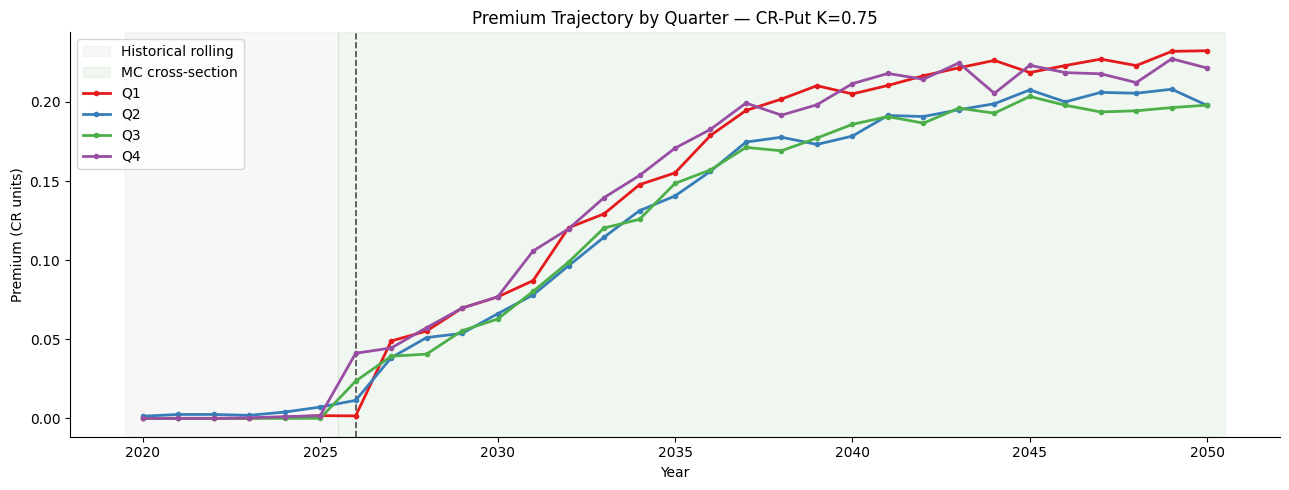

In [18]:
def step3_premium_trajectory(premium_roll, premium_mc):
    hist_q = (
        premium_roll.groupby(["year", "quarter"])["premium_roll"]
        .mean().reset_index()
        .rename(columns={"premium_roll": "premium"})
    )
    hist_q["source"] = "historical"

    sim_q = (
        premium_mc.groupby(["year", "quarter"])["premium_mc"]
        .mean().reset_index()
        .rename(columns={"premium_mc": "premium"})
    )
    sim_q["source"] = "simulated"

    combined = pd.concat([hist_q, sim_q], ignore_index=True)

    pivot = combined.pivot_table(index="year", columns="quarter", values="premium")
    pivot.columns = [f"Q{c}" for c in pivot.columns]
    print(pivot.to_string(float_format="{:.5f}".format))

    colors_q = {1: "#e41a1c", 2: "#377eb8", 3: "#4daf4a", 4: "#984ea3"}
    hist_yrs = sorted(hist_q["year"].unique())
    sim_yrs  = sorted(sim_q["year"].unique())

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.axvspan(min(hist_yrs) - 0.5, 2025.5, alpha=0.06, color="grey",  label="Historical rolling")
    ax.axvspan(2025.5, max(sim_yrs) + 0.5,  alpha=0.06, color="green", label="MC cross-section")
    ax.axvline(2026, color="black", lw=1.2, linestyle="--", alpha=0.7)

    for q in [1, 2, 3, 4]:
        sub = combined[combined["quarter"] == q].sort_values("year")
        ax.plot(sub["year"], sub["premium"], color=colors_q[q], lw=2,
                marker="o", ms=3, label=f"Q{q}")

    ax.set_title("Premium Trajectory by Quarter — CR-Put K=0.75")
    ax.set_xlabel("Year")
    ax.set_ylabel("Premium (CR units)")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()
    return combined


combined_premium = step3_premium_trajectory(premium_roll, premium_mc)

## Step 4 — Single Month Example: June 2026

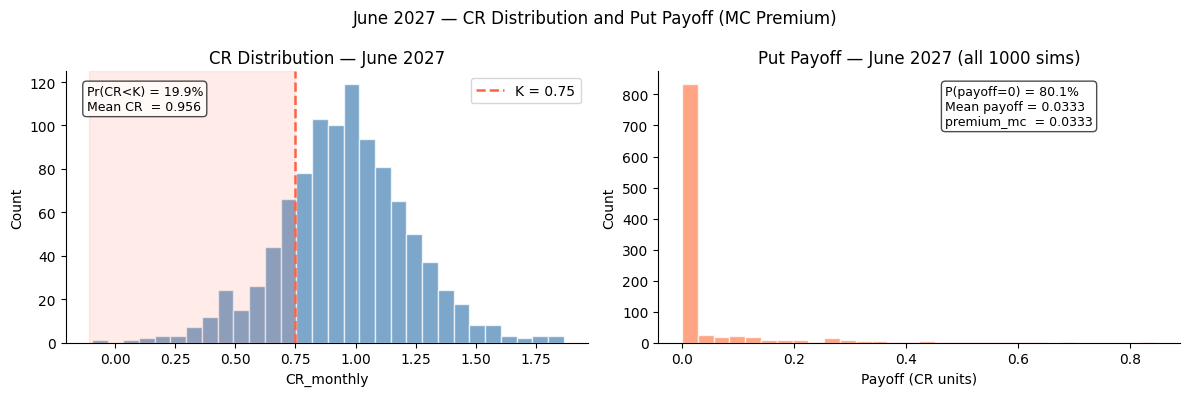

Pr(CR<K)   : 19.9%
Severity   : 0.1673 CR units
premium_mc : 0.0333 CR units


In [19]:
def step4_june_example(cr_monthly, premium_mc, K=K_CR):
    cr_june     = cr_monthly.loc[
        (cr_monthly["year"] == 2027) & (cr_monthly["month"] == 6), "CR_monthly"
    ]
    payoff_june = (K - cr_june).clip(lower=0)
    prem_june   = premium_mc.loc[
        (premium_mc["year"] == 2027) & (premium_mc["month"] == 6), "premium_mc"
    ].iloc[0]

    freq        = (cr_june < K).mean()
    severity_cr = (K - cr_june[cr_june < K]).mean() if (cr_june < K).any() else 0.0

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.hist(cr_june, bins=30, color="steelblue", alpha=0.7, edgecolor="white")
    ax.axvline(K, color="tomato", lw=1.8, linestyle="--", label=f"K = {K}")
    ax.axvspan(cr_june.min() - 0.01, K, alpha=0.12, color="tomato")
    ax.set_title("CR Distribution — June 2027")
    ax.set_xlabel("CR_monthly")
    ax.set_ylabel("Count")
    ax.text(0.04, 0.95, f"Pr(CR<K) = {freq:.1%}\nMean CR  = {cr_june.mean():.3f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))
    ax.legend()

    ax = axes[1]
    ax.hist(payoff_june, bins=30, color="coral", alpha=0.7, edgecolor="white")
    ax.set_title("Put Payoff — June 2027 (all 1000 sims)")
    ax.set_xlabel("Payoff (CR units)")
    ax.set_ylabel("Count")
    ax.text(0.55, 0.95,
            f"P(payoff=0) = {1 - freq:.1%}\nMean payoff = {payoff_june.mean():.4f}\npremium_mc  = {prem_june:.4f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))

    fig.suptitle("June 2027 — CR Distribution and Put Payoff (MC Premium)")
    sns.despine()
    plt.tight_layout()
    plt.show()

    print(f"Pr(CR<K)   : {freq:.1%}")
    print(f"Severity   : {severity_cr:.4f} CR units")
    print(f"premium_mc : {prem_june:.4f} CR units")


step4_june_example(cr_monthly, premium_mc)

## Step 5 — Apply Hedge (Forward 2026–2050)

In [20]:
def step5_apply_hedge(cr_monthly, ri, premium_mc, K=K_CR):
    cr = cr_monthly.merge(premium_mc[["year", "month", "premium_mc"]], on=["year", "month"])
    cr["payoff_sim"] = (K - cr["CR_monthly"]).clip(lower=0)
    cr["net_sim"]    = cr["payoff_sim"] - cr["premium_mc"]

    annual_net = (
        cr.groupby(["sim_id", "year"])["net_sim"]
        .sum()
        .reset_index()
        .rename(columns={"net_sim": "annual_net_sim"})
    )

    merged = ri.merge(annual_net, on=["sim_id", "year"], how="inner")
    merged["RI_sim_hedged"]   = merged["RI_annual"] + merged["PR_annual"] * merged["annual_net_sim"] / 12
    merged["RI_sim_unhedged"] = merged["RI_annual"]

    print(f"ri_sim shape    : {merged.shape}")
    print(f"Mean annual_net : {merged['annual_net_sim'].mean():.6f}  (≈0 by fair-premium construction)")
    return merged


ri_sim = step5_apply_hedge(cr_monthly, ri, premium_mc)

ri_sim shape    : (25000, 8)
Mean annual_net : 0.000000  (≈0 by fair-premium construction)


## Step 6 — Risk Analysis at Target Years


── 2030 ─────────────────────────────────────────
Metric         Unhedged       Hedged      Delta
mean             928.44       927.34      -1.10
std              188.90       135.54     -53.36
P10              689.83       766.19     +76.36
P50              938.77       921.56     -17.21
P90             1152.58      1100.84     -51.74
VaR95            593.17       726.97    +133.80
CVaR95           505.50       674.12    +168.63
var_red                                  +48.5%

── 2040 ─────────────────────────────────────────
Metric         Unhedged       Hedged      Delta
mean             660.05       654.73      -5.32
std              186.04       111.19     -74.85
P10              432.54       553.57    +121.04
P50              651.32       647.59      -3.73
P90              884.22       777.65    -106.58
VaR95            343.58       519.75    +176.17
CVaR95           248.02       415.98    +167.95
var_red                                  +64.3%

── 2050 ─────────────────────────

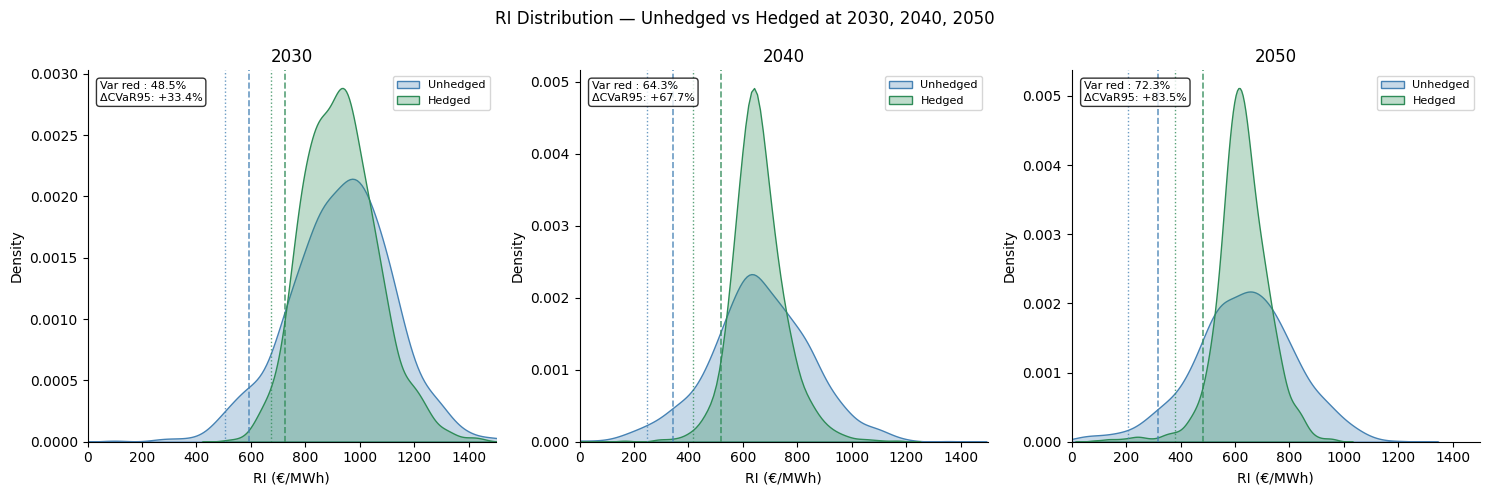

In [21]:
def step6_risk_analysis(ri_sim, target_years=TARGET_YEARS):
    records = []
    for y in target_years:
        sub = ri_sim[ri_sim["year"] == y]
        for label, col in [("Unhedged", "RI_sim_unhedged"), ("Hedged", "RI_sim_hedged")]:
            s      = sub[col]
            var95  = s.quantile(0.05)
            cvar95 = s[s <= var95].mean()
            records.append({
                "year": y, "series": label,
                "mean": s.mean(), "std": s.std(),
                "P10": s.quantile(0.10), "P50": s.quantile(0.50),
                "P90": s.quantile(0.90), "VaR95": var95, "CVaR95": cvar95,
            })

    risk = pd.DataFrame(records)

    for y in target_years:
        sub  = ri_sim[ri_sim["year"] == y]
        vr   = 1 - sub["RI_sim_hedged"].var() / sub["RI_sim_unhedged"].var()
        u    = risk[(risk["year"] == y) & (risk["series"] == "Unhedged")].iloc[0]
        h    = risk[(risk["year"] == y) & (risk["series"] == "Hedged")].iloc[0]
        print(f"\n── {y} ─────────────────────────────────────────")
        print(f"{'Metric':<10} {'Unhedged':>12} {'Hedged':>12} {'Delta':>10}")
        for m in ["mean", "std", "P10", "P50", "P90", "VaR95", "CVaR95"]:
            print(f"{m:<10} {u[m]:>12.2f} {h[m]:>12.2f} {h[m]-u[m]:>+10.2f}")
        print(f"{'var_red':<10} {'':>12} {'':>12} {vr:>+10.1%}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, y in zip(axes, target_years):
        sub  = ri_sim[ri_sim["year"] == y]
        vr   = 1 - sub["RI_sim_hedged"].var() / sub["RI_sim_unhedged"].var()
        u    = risk[(risk["year"] == y) & (risk["series"] == "Unhedged")].iloc[0]
        h    = risk[(risk["year"] == y) & (risk["series"] == "Hedged")].iloc[0]
        dcvar = (h["CVaR95"] - u["CVaR95"]) / abs(u["CVaR95"]) * 100

        sns.kdeplot(sub["RI_sim_unhedged"], ax=ax, color="steelblue", fill=True,
                    alpha=0.3, label="Unhedged")
        sns.kdeplot(sub["RI_sim_hedged"],   ax=ax, color="seagreen",  fill=True,
                    alpha=0.3, label="Hedged")

        for row, c in [(u, "steelblue"), (h, "seagreen")]:
            ax.axvline(row["VaR95"],  color=c, lw=1.2, linestyle="--", alpha=0.8)
            ax.axvline(row["CVaR95"], color=c, lw=1.0, linestyle=":",  alpha=0.8)

        ax.text(0.03, 0.97, f"Var red : {vr:.1%}\nΔCVaR95: {dcvar:+.1f}%",
                transform=ax.transAxes, va="top", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))
        ax.set_title(str(y))
        ax.set_xlabel("RI (€/MWh)")
        ax.set_xlim(0, 1500)
        ax.legend(fontsize=8)

    fig.suptitle("RI Distribution — Unhedged vs Hedged at 2030, 2040, 2050")
    sns.despine()
    plt.tight_layout()
    plt.show()
    return risk


risk_table = step6_risk_analysis(ri_sim)

## Step 7 — VaR95 and CVaR95 Time Series 2026–2050

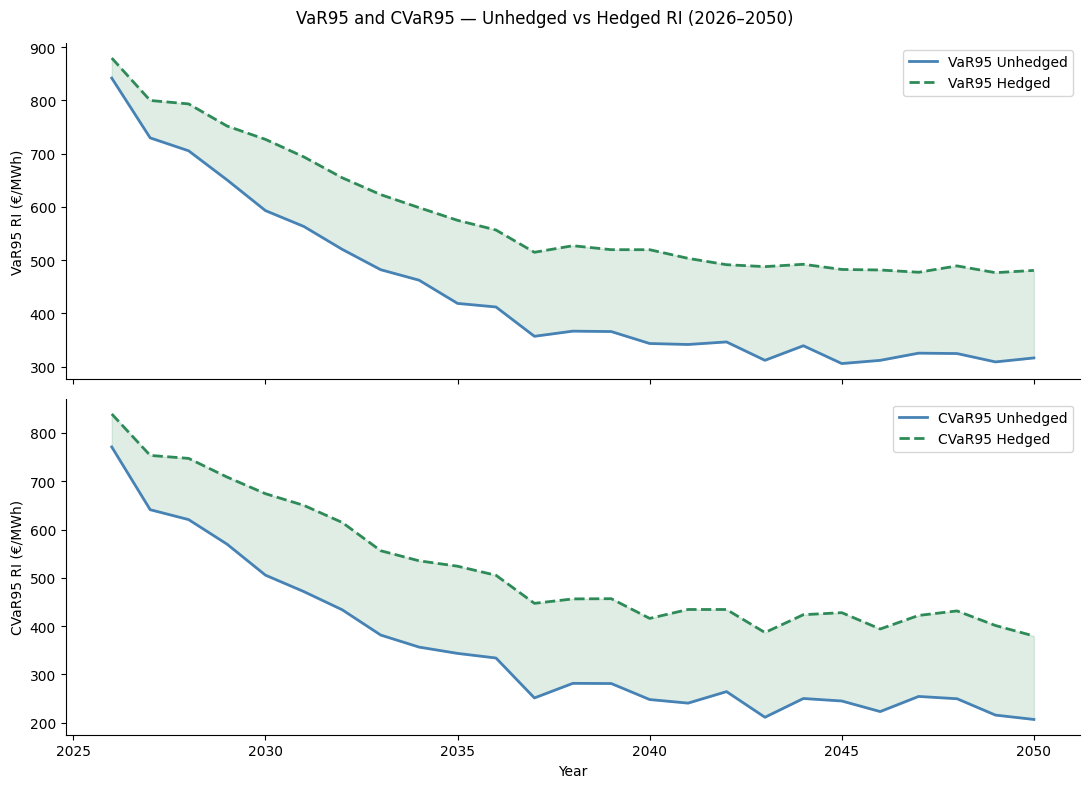

In [22]:
def step7_risk_timeseries(ri_sim):
    rows = []
    for y, grp in ri_sim.groupby("year"):
        for label, col in [("Unhedged", "RI_sim_unhedged"), ("Hedged", "RI_sim_hedged")]:
            s      = grp[col]
            var95  = s.quantile(0.05)
            cvar95 = s[s <= var95].mean()
            rows.append({"year": y, "series": label, "VaR95": var95, "CVaR95": cvar95})

    ts  = pd.DataFrame(rows)
    unh = ts[ts["series"] == "Unhedged"].sort_values("year")
    hed = ts[ts["series"] == "Hedged"].sort_values("year")

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

    ax = axes[0]
    ax.plot(unh["year"], unh["VaR95"], color="steelblue", lw=2, label="VaR95 Unhedged")
    ax.plot(hed["year"], hed["VaR95"], color="seagreen",  lw=2, linestyle="--", label="VaR95 Hedged")
    ax.fill_between(unh["year"], unh["VaR95"], hed["VaR95"], alpha=0.15, color="seagreen")
    ax.set_ylabel("VaR95 RI (€/MWh)")
    ax.legend()

    ax = axes[1]
    ax.plot(unh["year"], unh["CVaR95"], color="steelblue", lw=2, label="CVaR95 Unhedged")
    ax.plot(hed["year"], hed["CVaR95"], color="seagreen",  lw=2, linestyle="--", label="CVaR95 Hedged")
    ax.fill_between(unh["year"], unh["CVaR95"], hed["CVaR95"], alpha=0.15, color="seagreen")
    ax.set_ylabel("CVaR95 RI (€/MWh)")
    ax.set_xlabel("Year")
    ax.legend()

    fig.suptitle("VaR95 and CVaR95 — Unhedged vs Hedged RI (2026–2050)")
    sns.despine()
    plt.tight_layout()
    plt.show()
    return ts


risk_ts = step7_risk_timeseries(ri_sim)

## Step 8 — Cumulative Variance Reduction

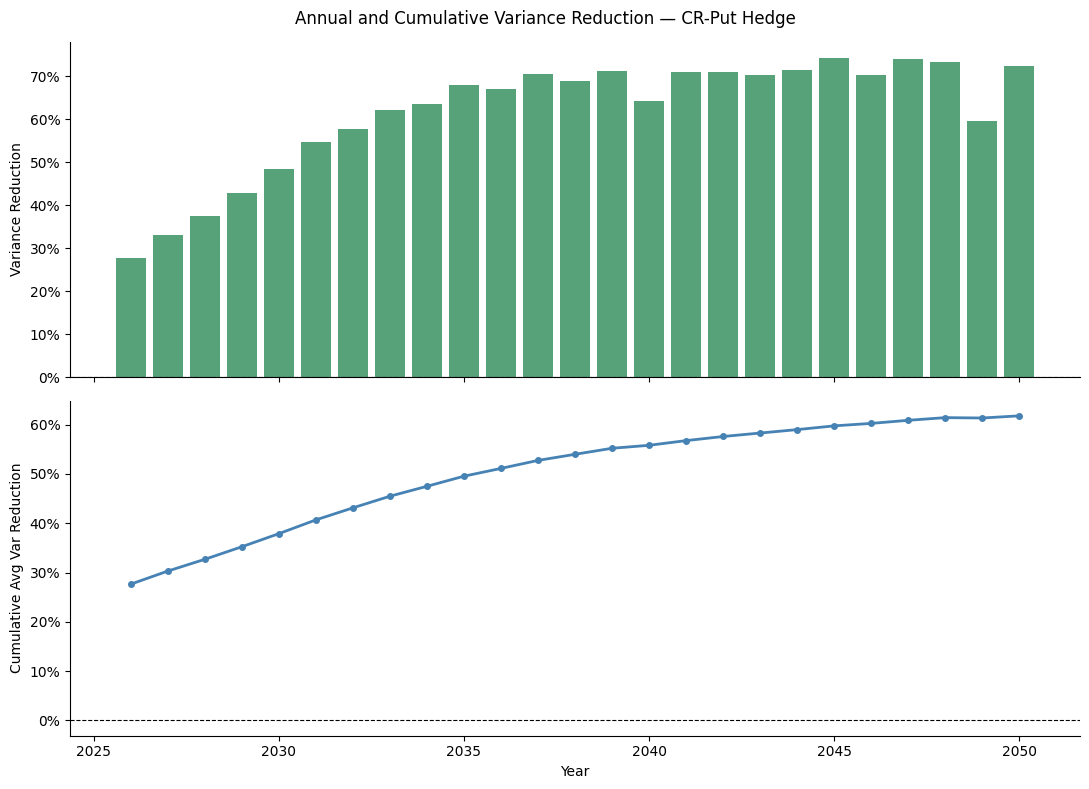

In [23]:
def step8_variance_reduction(ri_sim):
    rows = []
    for y, grp in ri_sim.groupby("year"):
        var_unh = grp["RI_sim_unhedged"].var()
        var_hed = grp["RI_sim_hedged"].var()
        vr = (1 - var_hed / var_unh) if var_unh >= 1e-8 else np.nan
        rows.append({"year": y, "var_red": vr})

    var_df = pd.DataFrame(rows).sort_values("year")
    var_df["cum_avg"] = var_df["var_red"].expanding().mean()

    colors = ["seagreen" if v >= 0 else "tomato" for v in var_df["var_red"]]

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

    axes[0].bar(var_df["year"], var_df["var_red"], color=colors, alpha=0.8)
    axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
    axes[0].set_ylabel("Variance Reduction")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

    axes[1].plot(var_df["year"], var_df["cum_avg"], color="steelblue", lw=2, marker="o", ms=4)
    axes[1].axhline(0, color="black", lw=0.8, linestyle="--")
    axes[1].set_ylabel("Cumulative Avg Var Reduction")
    axes[1].set_xlabel("Year")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

    fig.suptitle("Annual and Cumulative Variance Reduction — CR-Put Hedge")
    sns.despine()
    plt.tight_layout()
    plt.show()
    return var_df


var_df = step8_variance_reduction(ri_sim)